## Data Normalization with Pandas

Data normalization is the process of scaling numeric features to a standard range, preventing large values from dominating the learning process in machine learning models. It is a important step in machine learning and data analysis ensure that numerical features are on a similar scale for optimal model performance. Normalization helps to improve algorithm performance particularly for distance-based models like K-Nearest Neighbors (KNN) and Support Vector Machines (SVM). It is important because:

- Avoids numerical instability in models
- Speeds up convergence in gradient-based algorithms
- Ensures all features contribute equally to the analysis

### Steps for Data Normalization in Pandas
Here we will apply some techniques to normalize the data and discuss these with the help of examples. For this let's understand the steps needed for data normalization with Pandas.

- Import the required libraries
- Load or create a dataset
- Apply different normalization techniques
- Visualize the results

    Col A  Col B  Col C  Col D
0  180000    110   18.9   1400
1  360000    905   23.4   1800
2  230000    230   14.0   1300
3   60000    450   13.5   1500


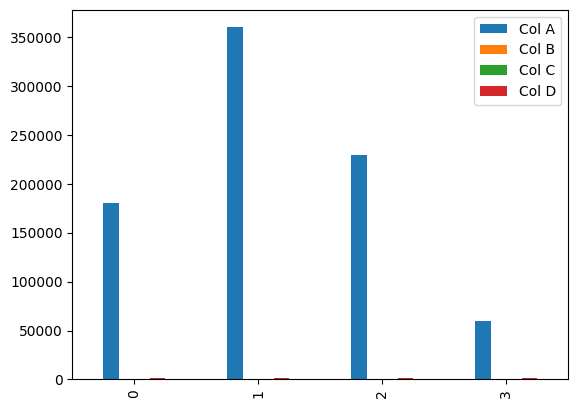

In [1]:
import pandas as pd  
import matplotlib.pyplot as plt  

df = pd.DataFrame([
    [180000, 110, 18.9, 1400],  
    [360000, 905, 23.4, 1800],  
    [230000, 230, 14.0, 1300],  
    [60000, 450, 13.5, 1500]
], columns=['Col A', 'Col B', 'Col C', 'Col D'])

print(df)

df.plot(kind='bar')
plt.show()

#### Description
Because Col A is much larger than other columns, its bars dominate the graph.
That is why:

- blue bars (Col A) are clearly visible
- orange, green, and red bars look almost flat near zero

This happens because all columns are plotted on the same y-axis scale.

Because of this:

- machine learning models may give more importance to large-scale columns
- visualization becomes misleading
- distance-based algorithms perform poorly

The given bar plot shows that the features are on different scales. Column A has values in lakhs, while Columns B, C, and D have much smaller ranges. Due to this scale difference, Column A dominates the visualization and hides the variation in other columns. Therefore, normalization is required to bring all features to a common range, usually between 0 and 1, so that each feature contributes equally during visualization and machine learning model training.

### Normalization Techniques in Pandas

#### 1. Maximum Absolute Scaling

This technique rescales each feature between -1 and 1 by dividing all values by the maximum absolute value in that column. This technique is especially useful when your data doesn’t contain negative numbers and you want to preserve the data’s sparsity. We can apply the maximum absolute scaling in Pandas using the .max() and .abs() methods as shown below. Let's apply normalization techniques one by one.

      Col A     Col B     Col C     Col D
0  0.500000  0.121547  0.807692  0.777778
1  1.000000  1.000000  1.000000  1.000000
2  0.638889  0.254144  0.598291  0.722222
3  0.166667  0.497238  0.576923  0.833333


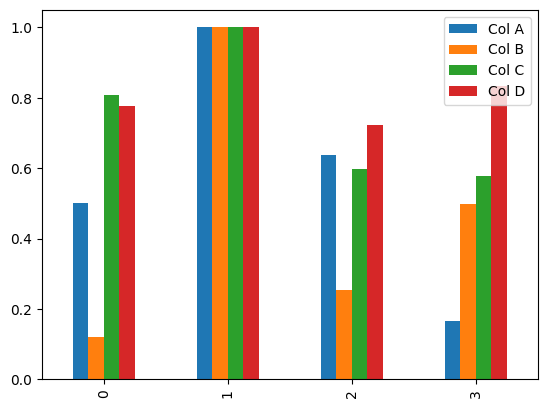

In [3]:
max_scaled = df.copy()

for column in max_scaled.columns:
    max_scaled[column] = max_scaled[column] / max_scaled[column].abs().max()

print(max_scaled)

max_scaled.plot(kind='bar')
plt.show()

#### Description

After absolute scaling, each column is normalized relative to its maximum value. The maximum value in every column becomes 1, and all other values are represented as fractions of that maximum. This makes columns with different ranges directly comparable on the same scale.

#### 2. The min-max feature scaling
The min-max approach also called normalization rescales the feature to a hard and fast range of [0,1] by subtracting the minimum value of the feature then dividing by the range. . It works well for models like K-Nearest Neighbors (KNN) which compare distance between data points. We can apply the min-max scaling in Pandas using the .min() and .max() methods.

      Col A     Col B     Col C  Col D
0  0.400000  0.000000  0.545455    0.2
1  1.000000  1.000000  1.000000    1.0
2  0.566667  0.150943  0.050505    0.0
3  0.000000  0.427673  0.000000    0.4


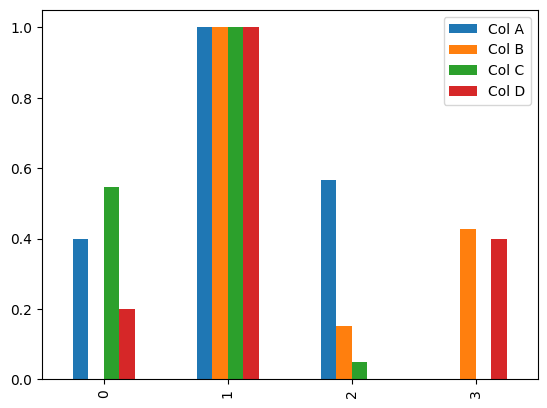

In [5]:
scaled = df.copy()

for column in scaled.columns:
    scaled[column] = (scaled[column] - scaled[column].min()) / (scaled[column].max() - scaled[column].min())

print(scaled)
scaled.plot(kind='bar')
plt.show()

#### Description
After scaling the smallest value becomes 0 and the largest becomes 1. All other values lie between these two. This makes it easier for the machine learning model to handle features fairly.

#### 3. The z-score method
The z-score method often called standardization changes the values in each column so that they have a mean of 0 and a standard deviation of 1. This technique is best when your data follow a normal distribution or when you want to treat values in terms of how far they are from the average.

      Col A     Col B     Col C    Col D
0 -0.221422 -0.895492  0.311486 -0.46291
1  1.227884  1.373564  1.278167  1.38873
2  0.181163 -0.552993 -0.741122 -0.92582
3 -1.187625  0.074922 -0.848531  0.00000


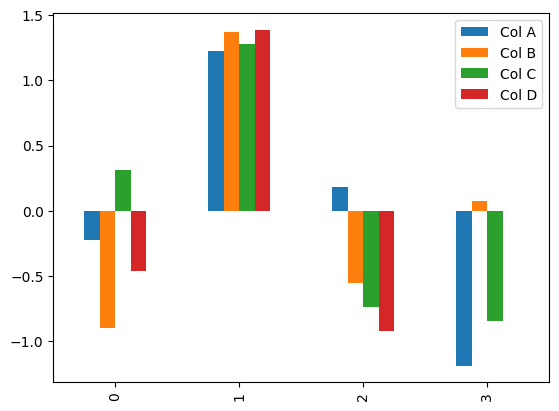

In [6]:
z_scaled = df.copy()

for column in z_scaled.columns:
    z_scaled[column] = (z_scaled[column] - z_scaled[column].mean()) / z_scaled[column].std()

print(z_scaled)

z_scaled.plot(kind='bar')
plt.show()

### Which algorithm is best for which case ?
There is no single “best” scaling method for all cases. The best scaling depends on the data distribution and the algorithm you are using.

First: understand what each scaling does

#### 1) Max / Absolute Scaling

formula: x_scaled = x / max(|x|)

##### Best use case
- you want to preserve sparsity
- values are already centered near zero
- large max value is meaningful

#### 2) Min-Max Scaling

Formula: x_scaled = (x - min) / (max - min)

##### Best use case
- Very useful when algorithms need a fixed bounded range.
- KNN
- K-Means
- Neural Networks
- Gradient Descent based algorithms

#### Why?
Because these algorithms depend heavily on distance and scale.

#### 3) Z-Score Scaling / Standardization

Formula: x_scaled = (x - mean) / std

##### Best use case
- This is the most commonly used scaling technique in machine learning.
- Linear Regression
- Logistic Regression
- SVM
- PCA
- K-Means
- Neural Networks
- Especially when data is approximately normally distributed.

#### Which one is best?
The real answer is: Best depends on algorithm + data distribution


- If data has outliers, Use Z-score Because min-max gets badly affected.
- If data has no outliers and bounded range is needed, Use Min-Max
- If using sparse data, Use MaxAbsScaler Because it keeps zeros unchanged.

#### when scaling is NOT needed
Tree-based algorithms do not need scaling.

Examples:
- Decision Tree
- Random Forest
- XGBoost
- CatBoost

Because trees split like:
- if Salary > 50000:
- They care about order, not magnitude.

Whether salary is:

- 50000
- 0.5
- 5

the split logic remains same.

So scaling gives almost no benefit.

### Scaling

- Scaling is the general process of changing the range or magnitude of numerical data so that all features are on a similar scale.
- It helps prevent features with large values from dominating those with smaller values.
- Example: converting values like 1000, 2000, 3000 into 0.1, 0.2, 0.3.

### Normalization

- Normalization is a type of scaling that transforms data into a fixed range, usually 0 to 1.
- It is mainly used when you need all values within the same bounded interval.
- Example: [10, 20, 30] → [0, 0.5, 1]

### Standardization

- Standardization is another type of scaling where data is transformed so that:
- - mean = 0
- - standard deviation = 1
- It is useful when data follows a normal distribution and is commonly used in machine learning algorithms.


### Final One-line summary
- Scaling → general term
- Normalization → scales data to a fixed range (usually 0 to 1)
- Standardization → centers data around mean 0 with std 1